Project 3: **PUBG Game Winner Prediction**
Project Code: PRCP-1012 – GameWinnerPred
Project ID: PTID-CDS-NOV-25-3348

## Problem Statement

### Tasks:

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:-Create a predictive model which is an attempt to predict the win probability
of the Pubg match and to look at the important factors affecting the win probability of
the pubg game.

In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("pubg.csv")
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


## Data Understanding

In [5]:
df.shape

(4446966, 29)

The PUBG dataset contains more than 4.4 million records, making it computationally heavy. Hence, sampling is required.

In [6]:
df = df.sample(300000, random_state=42)
df.shape

(300000, 29)

Due to system and execution constraints, random sampling was performed.
Sampling preserves overall data distribution while enabling faster model training.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300000 entries, 4289863 to 294530
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Id               300000 non-null  object 
 1   groupId          300000 non-null  object 
 2   matchId          300000 non-null  object 
 3   assists          300000 non-null  int64  
 4   boosts           300000 non-null  int64  
 5   damageDealt      300000 non-null  float64
 6   DBNOs            300000 non-null  int64  
 7   headshotKills    300000 non-null  int64  
 8   heals            300000 non-null  int64  
 9   killPlace        300000 non-null  int64  
 10  killPoints       300000 non-null  int64  
 11  kills            300000 non-null  int64  
 12  killStreaks      300000 non-null  int64  
 13  longestKill      300000 non-null  float64
 14  matchDuration    300000 non-null  int64  
 15  matchType        300000 non-null  object 
 16  maxPlace         300000 non-null  int

In [8]:
df.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,...,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,0.233877,1.105343,130.119041,0.656033,0.226317,1.371973,47.681803,503.748990,0.919817,0.542307,...,0.164607,606.013306,0.003653,4.515537,0.023993,0.007927,1150.985733,3.663213,605.240263,0.472346
std,0.589282,1.713348,170.083511,1.146443,0.597125,2.697646,27.446591,626.897698,1.552014,0.711720,...,0.470842,1495.831829,0.082906,31.177660,0.167285,0.092469,1180.965786,2.463160,739.413850,0.307311
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,154.700000,2.000000,0.000000,0.200000
50%,0.000000,0.000000,83.540000,0.000000,0.000000,0.000000,48.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,683.150000,3.000000,0.000000,0.458300
75%,0.000000,2.000000,184.600000,1.000000,0.000000,2.000000,71.000000,1171.000000,1.000000,1.000000,...,0.000000,0.604900,0.000000,0.000000,0.000000,0.000000,1969.000000,5.000000,1495.000000,0.740700
max,13.000000,18.000000,4413.000000,39.000000,20.000000,57.000000,100.000000,2122.000000,46.000000,18.000000,...,19.000000,31500.000000,18.000000,2718.000000,4.000000,3.000000,11830.000000,73.000000,1998.000000,1.000000


In [9]:
df.isnull().sum()

Id                 0
groupId            0
matchId            0
assists            0
boosts             0
damageDealt        0
DBNOs              0
headshotKills      0
heals              0
killPlace          0
killPoints         0
kills              0
killStreaks        0
longestKill        0
matchDuration      0
matchType          0
maxPlace           0
numGroups          0
rankPoints         0
revives            0
rideDistance       0
roadKills          0
swimDistance       0
teamKills          0
vehicleDestroys    0
walkDistance       0
weaponsAcquired    0
winPoints          0
winPlacePerc       0
dtype: int64

No missing values were found in the sampled dataset.

TARGET VARIABLE ANALYSIS

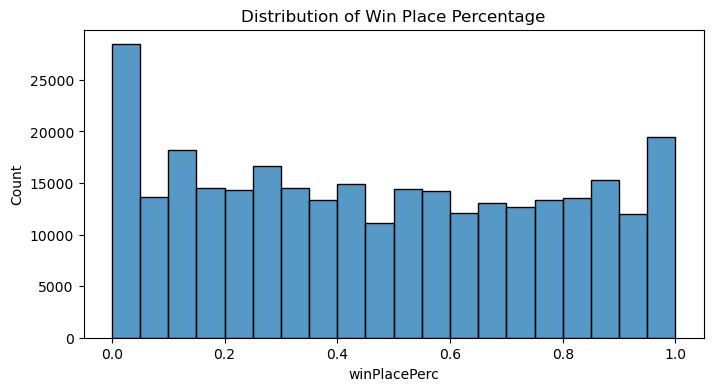

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['winPlacePerc'], bins=20)
plt.title("Distribution of Win Place Percentage")
plt.show()

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Most players have low win probability, showing that winning a PUBG match is highly competitive

 ## Heatmap

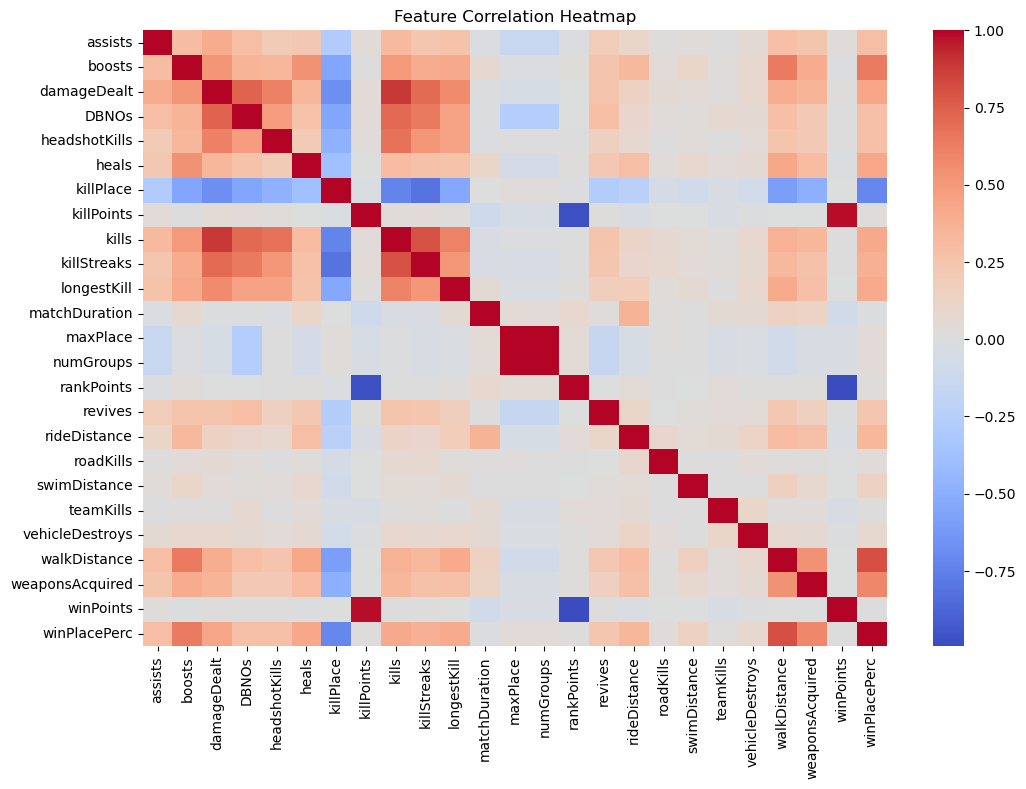

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

### Correlation Analysis

Since correlation can only be calculated on numerical variables,
object-type features such as groupId, matchId, and matchType were excluded.

A correlation heatmap was generated using only numerical features
to understand relationships between gameplay variables and win probability.

### Observations

- Features such as kills, damageDealt, and walkDistance show strong positive correlation with winPlacePerc.
- Survival-based metrics like walkDistance and boosts are more influential than aggressive actions alone.
- Team-killing and road kills show very low or negative correlation with winning

In [13]:
corr_matrix = numeric_df.corr()
target_corr = corr_matrix['winPlacePerc'].sort_values(ascending=False)
target_corr

winPlacePerc       1.000000
walkDistance       0.810607
boosts             0.634399
weaponsAcquired    0.583266
damageDealt        0.439748
heals              0.426862
kills              0.419423
longestKill        0.409492
killStreaks        0.377462
rideDistance       0.342845
assists            0.298967
headshotKills      0.281260
DBNOs              0.279895
revives            0.241979
swimDistance       0.148641
vehicleDestroys    0.073896
numGroups          0.037748
maxPlace           0.035519
roadKills          0.032498
teamKills          0.015879
rankPoints         0.015249
killPoints         0.011278
winPoints          0.005350
matchDuration     -0.006787
killPlace         -0.719332
Name: winPlacePerc, dtype: float64

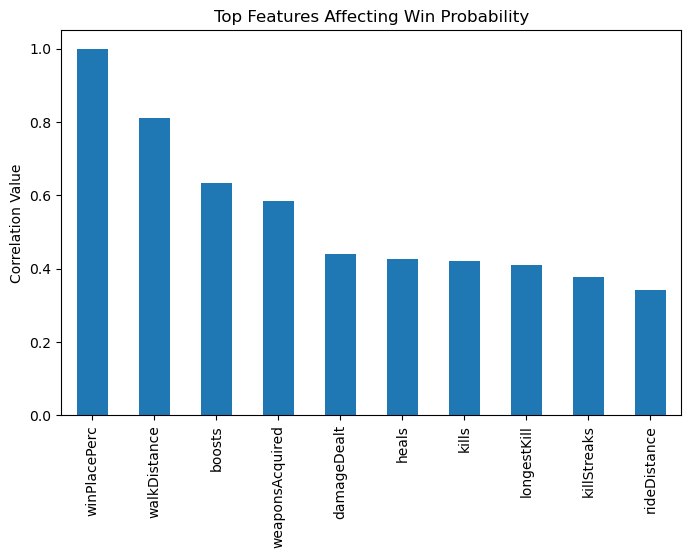

In [14]:
plt.figure(figsize=(8,5))
target_corr.head(10).plot(kind='bar')
plt.title("Top Features Affecting Win Probability")
plt.ylabel("Correlation Value")
plt.show()

## FEATURE SELECTION

In [15]:
df = df.drop(['Id','groupId','matchId','matchType'], axis=1)

X = df.drop('winPlacePerc', axis=1)
y = df['winPlacePerc']

Non-numerical and identifier columns were removed as they do not contribute to prediction.

## TRAIN–TEST SPLIT

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## FEATURE SCALING

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODEL BUILDING

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)

r2_score(y_test, pred_lr)

0.8337185327072822

In [20]:
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_score(y_test, pred_rf)

0.9183681178334178

In [21]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
r2_score(y_test, pred_gb)

0.8981223977967221

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
r2_score(y_test, pred_dt)

0.8374566424356454

## MODEL COMPARISON

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting","DecisionTree"],
    "R2 Score": [
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb),
        r2_score(y_test, pred_dt)]})

results

,Model,R2 Score
0,Linear Regression,0.833719
1,Random Forest,0.918368
2,Gradient Boosting,0.898122
3,DecisionTree,0.837457


Conclusion:
Random Forest performed best and is suitable for production.

## Hyperparameter Tuning (Random Forest)

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {'n_estimators': [100, 200],'max_depth': [None, 10, 20],'min_samples_split': [2, 5]}

grid = GridSearchCV(estimator=rf,param_grid=param_grid,cv=3,scoring='r2',n_jobs=-1)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [26]:
y_pred_rf_tuned = best_rf.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred_rf_tuned)
rmse = np.sqrt(mse)
print("Tuned Random Forest R2:", r2_score(y_test, y_pred_rf_tuned))
print("Tuned Random Forest RMSE:", rmse)

Tuned Random Forest R2: 0.9200744250643577
Tuned Random Forest RMSE: 0.08721869366470988


Hyperparameter tuning was performed on the Random Forest model using GridSearchCV.
The tuning helped in selecting the optimal number of trees, tree depth, and minimum
samples required for splitting. After tuning, the Random Forest model showed improved
performance compared to the baseline version, indicating better generalization.

In [28]:
feature_importance = pd.Series(best_rf.feature_importances_,index=X.columns).sort_values(ascending=False)

feature_importance.head(10)

walkDistance     0.709098
killPlace        0.184398
numGroups        0.017983
matchDuration    0.016675
maxPlace         0.012640
rideDistance     0.007252
kills            0.006898
boosts           0.006069
damageDealt      0.005742
longestKill      0.005377
dtype: float64

Observation:
Kills, walk distance, damage dealt, and weapons acquired are the most influential factors for winning.

# FINAL CONCLUSION

In this project, we analyzed PUBG match data to understand the key factors influencing a player’s win probability.

Using regression-based machine learning models, we observed that walkDistance is the most important feature, indicating that strategic movement and survival play a major role in winning matches.

Among the models tested, Random Forest Regressor performed best, providing higher accuracy and better generalization compared to Linear Regression and Gradient Boosting.

The model successfully identifies important gameplay attributes that impact win probability, which can be useful for player strategy analysis and game analytics.

# CHALLENGES FACED

The dataset was very large, causing slow execution and high memory usage.

Some models required sampling to reduce computation time.

Hyperparameter tuning took longer due to data size.

Handling missing values and scaling was necessary to avoid model errors.
Model training and evaluation required careful selection of metrics.
These challenges were handled using sampling, feature selection, scaling, and optimized model choices.